# import libereries

In [46]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step-by-Step Workflow

## Data Loading & Initial Exploration

In [47]:
df = pd.read_csv('creditcard.csv')
print(df.shape)
print(df['Class'].value_counts()) # It counts how many rows belong to each class, where 0 represents non-fraud and 1 represents fraud and prints the result.
print(df.isnull().sum().sum()) # Check for missing values

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64
0


## Exploratory Data Analysis (EDA)
### Visualize class distribution (bar chart)
### Analyze Amount and Time distributions
### Compare fraud vs. non-fraud transactions

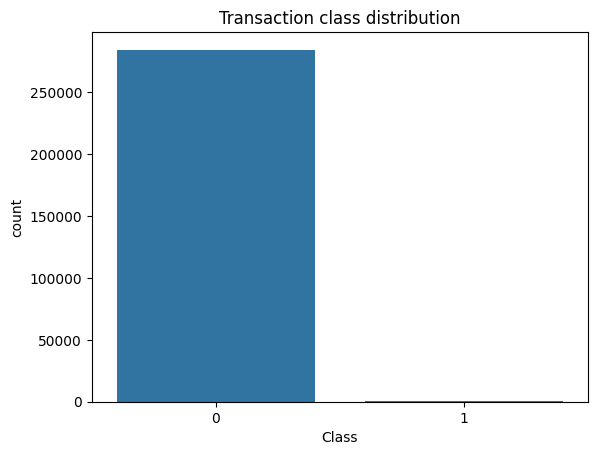

In [48]:
# Class distribution
sns.countplot(x = 'Class', data = df)
plt.title('Transaction class distribution')
plt.show()

c:\Users\njyot\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


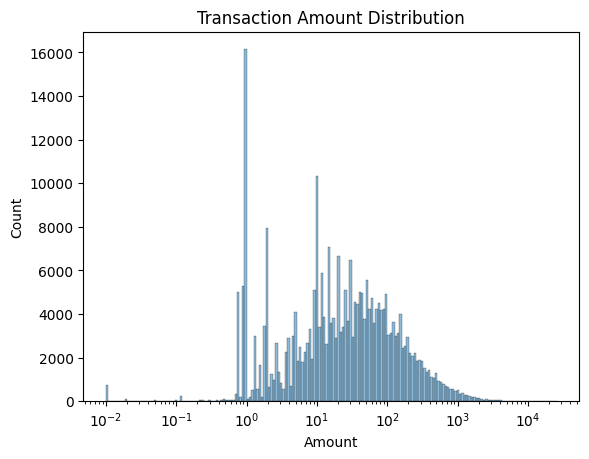

In [49]:
# Amount distribution (log scale)
sns.histplot(df['Amount'], log_scale = True, kde = True)
plt.title('Transaction Amount Distribution')
plt.show()

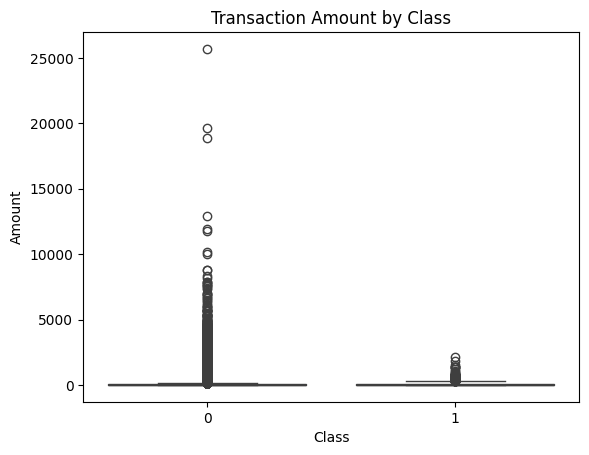

In [50]:
# Fraud vs Normal Amount
sns.boxplot(x = 'Class', y = 'Amount', data = df)
plt.title('Transaction Amount by Class')
plt.show()

## Data Preprocessing
### Scale Amount and Time (StandardScaler)
### Split into features (X) and target (y)

In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler

In [52]:
scaler = StandardScaler()
df[['Amount_Scaled', 'Time_Scaled']] = scaler.fit_transform(df[['Amount', 'Time']])
x = df[['Amount_Scaled', 'Time_Scaled']]
y = df['Class']

## Handle Imbalanced Data
### Use SMOTE or undersampling:

In [53]:
from imblearn.over_sampling import SMOTE

In [54]:
smote = SMOTE(random_state = 42)
x_resampled, y_resampled = smote.fit_resample(x,y)

## Train-Test Split

In [55]:
from sklearn.model_selection import train_test_split

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    x_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

## Model Training
#### Random Forest

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [58]:
model = RandomForestClassifier(n_estimators = 100, random_state = 42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[53611  3252]
 [ 1836 55027]]
              precision    recall  f1-score   support

           0       0.97      0.94      0.95     56863
           1       0.94      0.97      0.96     56863

    accuracy                           0.96    113726
   macro avg       0.96      0.96      0.96    113726
weighted avg       0.96      0.96      0.96    113726



## Evaluate Model
### Focus on:
#### Precision (minimize false positives)
#### Recall (catch as many frauds as possible)
#### F1-Score
#### ROC-AUC

In [59]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred)

0.9552608902098025

## Feature Importance

In [60]:
importances = model.feature_importances_
feature_names = x.columns
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance.sort_values('Importance', ascending=False).head(10)

,Feature,Importance
0,Amount_Scaled,0.518965
1,Time_Scaled,0.481035


In [61]:
import joblib

# Save the trained model to a .pkl file
joblib.dump(model, 'fraud_model.pkl')

# Save the scaler if you have one
joblib.dump(scaler, 'scaler.pkl')

print("Files created!")

Files created!
